Phase 1.4: Unsupervised Document Clustering

In [1]:
# Import libraries
import pandas as pd
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Load all splits
dataset = load_dataset("hpe-ai/medical-cases-classification-tutorial")
df_train = dataset['train'].to_pandas()
df_val = dataset['validation'].to_pandas()
df_test = dataset['test'].to_pandas()

# Create combined_text for consistency
df_train['combined_text'] = df_train['description'] + " " + df_train['transcription']
df_val['combined_text'] = df_val['description'] + " " + df_val['transcription']
df_test['combined_text'] = df_test['description'] + " " + df_test['transcription']

# Combine all data for clustering
all_df = pd.concat([df_train, df_val, df_test], ignore_index=True)
texts = all_df['combined_text'].tolist()
true_labels = all_df['medical_specialty'].tolist()

print(f"Total documents for clustering: {len(texts)}")

/home/tharu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Repo card metadata block was not found. Setting CardData to empty.


Total documents for clustering: 2464


In [2]:
# Vectorize with improved TF-IDF config
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=10000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.8
)

X_tfidf = vectorizer.fit_transform(texts)
print(f"TF-IDF matrix shape: {X_tfidf.shape}")

TF-IDF matrix shape: (2464, 10000)


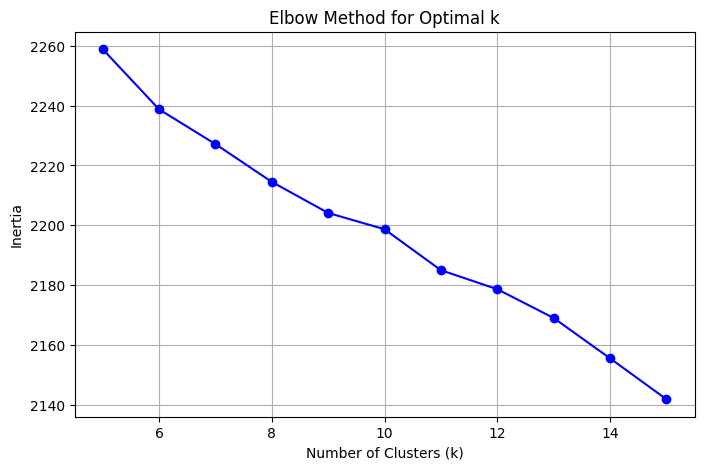

In [3]:
# Elbow method for optimal k
inertias = []
K_range = range(5, 16)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_tfidf)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [4]:
# Final clustering with k=8
best_k = 8
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_tfidf)
all_df['cluster'] = cluster_labels

# Analyze top words per cluster
feature_names = vectorizer.get_feature_names_out()
print(f"\n=== TOP WORDS PER CLUSTER (k={best_k}) ===")
for i in range(best_k):
    centroid = final_kmeans.cluster_centers_[i]
    top_indices = centroid.argsort()[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    print(f"\nCluster {i}:")
    print(", ".join(top_words))

# Map clusters to true specialties
cluster_specialty_map = all_df.groupby('cluster')['medical_specialty'].apply(lambda x: x.value_counts().head(3))
print("\n=== Top 3 True Specialties per Cluster ===")
for cluster_id in range(best_k):
    print(f"\nCluster {cluster_id}:")
    print(cluster_specialty_map[cluster_id])


=== TOP WORDS PER CLUSTER (k=8) ===

Cluster 0:
fetal, placenta, delivery, weeks days, weeks, uterus, pregnancy, labor, cord, gestation

Cluster 1:
history, mg, pain, past, normal, daily, denies, does, disease, medications

Cluster 2:
l5, l4, l4 l5, s1, l5 s1, lumbar, l3, disc, nerve root, disk

Cluster 3:
unremarkable, revealed, mri, left, right, 93, exam, weakness, brain, 95

Cluster 4:
stress, valve, normal, test, heart rate, exercise, aortic, stress test, ventricular, atrial

Cluster 5:
artery, coronary, left, coronary artery, right, catheter, right coronary, stenosis, vessel, french

Cluster 6:
c5, c6, c4, c5 c6, cervical, c4 c5, anterior cervical, c3, anterior, c7

Cluster 7:
right, procedure, left, placed, anesthesia, using, incision, removed, diagnosis, performed

=== Top 3 True Specialties per Cluster ===

Cluster 0:
Obstetrics / Gynecology    55
Radiology                   8
Name: medical_specialty, dtype: int64

Cluster 1:
Cardiovascular / Pulmonary    198
Neurology        